In [1]:
import os

print(os.listdir('/content'))

['.config', 'northstar_dataset.zip', 'sample_data']


In [2]:
import pandas as pd

In [3]:
import os

print(os.listdir('/content'))


['.config', 'northstar_dataset.zip', 'sample_data']


In [4]:
import zipfile
import os

zip_file = '/content/northstar_dataset.zip'

extract_folder = '/content/northstar_data'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP Extracted Successfully")

print(os.listdir(extract_folder))

ZIP Extracted Successfully
['northstar_dataset']


In [5]:
import pandas as pd

deliveries = pd.read_csv('/content/northstar_data/northstar_dataset/deliveries.csv')

print(deliveries.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

In [6]:
print(deliveries.columns)

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')


Convert Date Columns

In [7]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time']
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

print("Date Conversion Complete")

Date Conversion Complete


Create Delivery Duration KPI

In [8]:
deliveries['delivery_duration'] = (
    deliveries['delivery_completed_at']
    -
    deliveries['dispatch_time']
).dt.total_seconds() / 60

print(
    deliveries[
        [
            'dispatch_time',
            'delivery_completed_at',
            'delivery_duration'
        ]
    ].head()
)

        dispatch_time      delivery_completed_at  delivery_duration
0 2024-06-18 10:57:00 2024-06-19 09:05:59.904311        1328.998405
1 2025-01-11 18:45:00 2025-01-11 17:39:00.000000         -66.000000
2 2025-06-02 20:39:00 2025-06-02 21:45:32.366770          66.539446
3 2024-03-08 23:31:00 2024-03-09 23:30:08.103702        1439.135062
4 2025-09-21 11:43:00 2025-09-21 15:45:34.131056         242.568851


Checking Missing Values

In [9]:
print(deliveries.isnull().sum())

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
delivery_duration                19
dtype: int64


Basic Statistics

In [10]:
print(deliveries.describe())

                       dispatch_time          delivery_completed_at  \
count                            950                            931   
mean   2024-12-20 13:10:27.536841984  2024-12-19 20:19:52.772387584   
min              2024-01-01 03:20:00     2024-01-01 15:35:48.325916   
25%              2024-06-21 17:54:00  2024-06-18 14:13:03.296665088   
50%              2024-12-12 14:19:30  2024-12-13 02:04:50.318852096   
75%              2025-06-12 01:39:15  2025-06-12 00:14:26.336295936   
max              2025-12-31 17:27:00     2025-12-31 18:05:52.415764   
std                              NaN                            NaN   

       route_distance_km  manual_route_override_count  \
count         950.000000                   950.000000   
mean           13.909316                     0.969474   
min             1.200000                     0.000000   
25%             9.135000                     0.000000   
50%            12.840000                     1.000000   
75%            16.

Delivery Status Distribution

In [11]:
print(
    deliveries['delivery_status']
    .value_counts()
)

delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


Average Delivery Duration

In [12]:
print(
    "Average Delivery Duration (Minutes):"
)

print(
    deliveries['delivery_duration']
    .mean()
)

Average Delivery Duration (Minutes):
572.7291638523452


Driver Performance Analysis

In [13]:
driver_performance = deliveries.groupby(
    'driver_id'
)['delivery_duration'].mean()

print(
    driver_performance.sort_values(
        ascending=False
    )
)

driver_id
D063    1303.750925
D062    1261.362154
D040    1124.622132
D023    1117.948473
D055    1109.522533
           ...     
D038     134.931084
D118     113.896026
D169      98.002251
D160      49.063099
D065     -44.334934
Name: delivery_duration, Length: 170, dtype: float64


Route Override Analysis

In [14]:
override_analysis = deliveries.groupby(
    'manual_route_override_count'
)['delivery_duration'].mean()

print(override_analysis)

manual_route_override_count
0     583.461679
1     574.491035
2     552.616352
3     521.001870
4     588.370709
5     594.069666
7    1293.135841
Name: delivery_duration, dtype: float64


Customer Rating Analysis

In [15]:
rating_analysis = deliveries.groupby(
    'delivery_status'
)['customer_rating_post_delivery'].mean()

print(rating_analysis)

delivery_status
Delayed    3.114975
Failed     3.049313
OnTime     4.283273
Name: customer_rating_post_delivery, dtype: float64


Fuel Cost Analysis

In [16]:
fuel_analysis = deliveries.groupby(
    'delivery_status'
)['fuel_or_charge_cost'].mean()

print(fuel_analysis)

delivery_status
Delayed    13.138713
Failed     13.147955
OnTime     12.678052
Name: fuel_or_charge_cost, dtype: float64


Delivery Duration Histogram

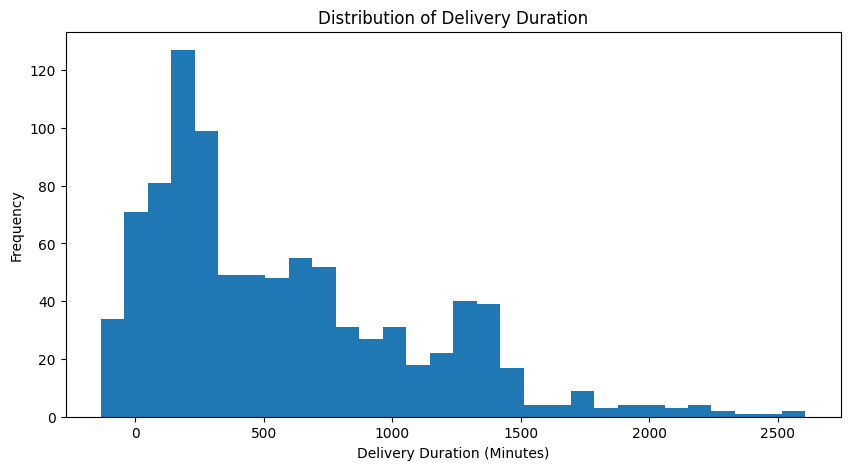

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    deliveries['delivery_duration'],
    bins=30
)

plt.xlabel('Delivery Duration (Minutes)')
plt.ylabel('Frequency')

plt.title(
    'Distribution of Delivery Duration'
)

plt.show()

Delivery Status Bar Chart

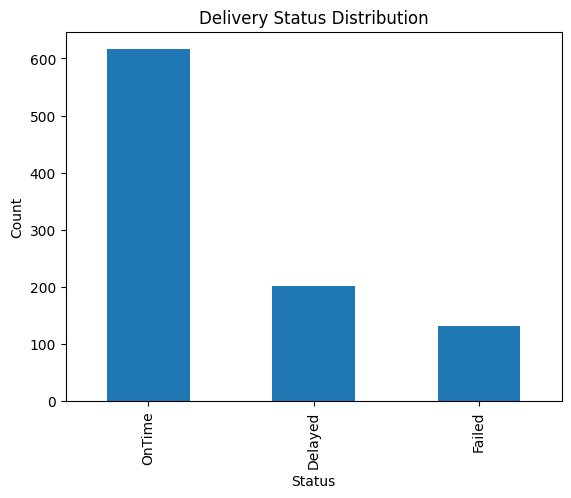

In [18]:
deliveries[
    'delivery_status'
].value_counts().plot(
    kind='bar'
)

plt.title(
    'Delivery Status Distribution'
)

plt.xlabel('Status')
plt.ylabel('Count')

plt.show()

Driver Performance Chart

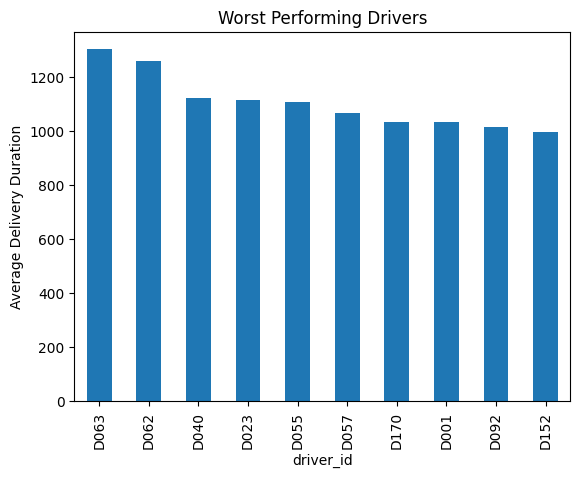

In [19]:
top_drivers = deliveries.groupby(
    'driver_id'
)['delivery_duration'].mean().sort_values(
    ascending=False
).head(10)

top_drivers.plot(kind='bar')

plt.title(
    'Worst Performing Drivers'
)

plt.ylabel(
    'Average Delivery Duration'
)

plt.show()

Route Override Scatterplot

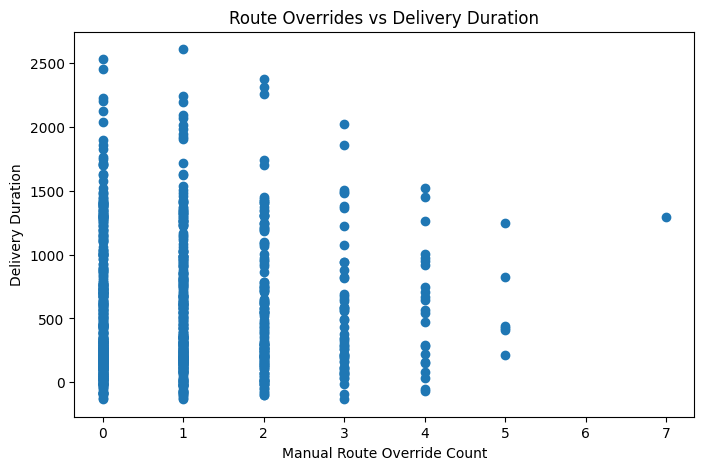

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    deliveries[
        'manual_route_override_count'
    ],
    deliveries[
        'delivery_duration'
    ]
)

plt.xlabel(
    'Manual Route Override Count'
)

plt.ylabel(
    'Delivery Duration'
)

plt.title(
    'Route Overrides vs Delivery Duration'
)

plt.show()

Correlation Analysis

In [21]:
correlation = deliveries[
    [
        'route_distance_km',
        'manual_route_override_count',
        'fuel_or_charge_cost',
        'customer_rating_post_delivery',
        'delivery_duration'
    ]
].corr()

print(correlation)

                               route_distance_km  manual_route_override_count  \
route_distance_km                       1.000000                     0.202296   
manual_route_override_count             0.202296                     1.000000   
fuel_or_charge_cost                     0.524194                     0.098690   
customer_rating_post_delivery           0.028525                    -0.059903   
delivery_duration                       0.020505                    -0.013711   

                               fuel_or_charge_cost  \
route_distance_km                         0.524194   
manual_route_override_count               0.098690   
fuel_or_charge_cost                       1.000000   
customer_rating_post_delivery            -0.059062   
delivery_duration                         0.049378   

                               customer_rating_post_delivery  \
route_distance_km                                   0.028525   
manual_route_override_count                        -0.059903

Saving Cleaned Dataset

In [22]:
deliveries.to_csv(
    '/content/cleaned_deliveries.csv',
    index=False
)

print(
    'Cleaned Dataset Saved Successfully'
)

Cleaned Dataset Saved Successfully


In [23]:
print(os.listdir('/content/northstar_data'))

['northstar_dataset']


In [24]:
import os

print(
    os.listdir(
        '/content/northstar_data/northstar_dataset'
    )
)


['incidents.csv', 'deliveries.csv', 'customers.csv', 'data_dictionary.csv', 'app_events.csv', 'orders.csv', 'drivers.csv', 'complaints.csv', 'README.txt', 'hubs.csv', 'vehicles.csv']


Loading all Dataset

In [25]:
import pandas as pd

deliveries = pd.read_csv(
    '/content/northstar_data/northstar_dataset/deliveries.csv'
)

drivers = pd.read_csv(
    '/content/northstar_data/northstar_dataset/drivers.csv'
)

vehicles = pd.read_csv(
    '/content/northstar_data/northstar_dataset/vehicles.csv'
)

complaints = pd.read_csv(
    '/content/northstar_data/northstar_dataset/complaints.csv'
)

incidents = pd.read_csv(
    '/content/northstar_data/northstar_dataset/incidents.csv'
)

orders = pd.read_csv(
    '/content/northstar_data/northstar_dataset/orders.csv'
)

customers = pd.read_csv(
    '/content/northstar_data/northstar_dataset/customers.csv'
)

hubs = pd.read_csv(
    '/content/northstar_data/northstar_dataset/hubs.csv'
)

app_events = pd.read_csv(
    '/content/northstar_data/northstar_dataset/app_events.csv'
)

print("All Datasets Loaded Successfully")

All Datasets Loaded Successfully


Checking all Datasets

In [26]:
print(deliveries.head())

print(drivers.head())

print(vehicles.head())

print(complaints.head())

print(incidents.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

Checking Column Names

In [27]:
print(drivers.columns)

print(vehicles.columns)

print(complaints.columns)

print(incidents.columns)

print(orders.columns)

print(customers.columns)

print(hubs.columns)

print(app_events.columns)

Index(['driver_id', 'base_zone', 'employment_type', 'years_experience',
       'training_score', 'driver_rating', 'shift_preference', 'active_flag'],
      dtype='object')
Index(['vehicle_id', 'vehicle_type', 'assigned_zone', 'commission_date',
       'battery_health_pct', 'odometer_km', 'maintenance_status',
       'telematics_version'],
      dtype='object')
Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')
Index(['incident_id', 'delivery_id', 'incident_type', 'reported_at',
       'severity', 'resolution_status', 'resolved_hours'],
      dtype='object')
Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')
Index(['customer_id', 'age', 'home_zone', 'cus

Checking Missing Values

In [28]:
print(deliveries.isnull().sum())

print(drivers.isnull().sum())

print(vehicles.isnull().sum())

print(complaints.isnull().sum())

print(incidents.isnull().sum())

delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
driver_id           0
base_zone           0
employment_type     0
years_experience    0
training_score      7
driver_rating       0
shift_preference    0
active_flag         0
dtype: int64
vehicle_id            0
vehicle_type          0
assigned_zone         0
commission_date       0
battery_health_pct    4
odometer_km           0
maintenance_status    0
telematics_version    0
dtype: int64
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel              

Creating Delivery Duration Again

In [29]:
deliveries['dispatch_time'] = pd.to_datetime(
    deliveries['dispatch_time']
)

deliveries['delivery_completed_at'] = pd.to_datetime(
    deliveries['delivery_completed_at']
)

deliveries['delivery_duration'] = (
    deliveries['delivery_completed_at']
    -
    deliveries['dispatch_time']
).dt.total_seconds() / 60

print(
    deliveries[
        [
            'dispatch_time',
            'delivery_completed_at',
            'delivery_duration'
        ]
    ].head()
)

        dispatch_time      delivery_completed_at  delivery_duration
0 2024-06-18 10:57:00 2024-06-19 09:05:59.904311        1328.998405
1 2025-01-11 18:45:00 2025-01-11 17:39:00.000000         -66.000000
2 2025-06-02 20:39:00 2025-06-02 21:45:32.366770          66.539446
3 2024-03-08 23:31:00 2024-03-09 23:30:08.103702        1439.135062
4 2025-09-21 11:43:00 2025-09-21 15:45:34.131056         242.568851


Merging Datasets

In [30]:
merged = deliveries.merge(
    drivers,
    on='driver_id',
    how='left'
)

merged = merged.merge(
    vehicles,
    on='vehicle_id',
    how='left'
)

merged = merged.merge(
    orders,
    on='order_id',
    how='left'
)

merged = merged.merge(
    customers,
    on='customer_id',
    how='left'
)

merged = merged.merge(
    hubs,
    on='hub_id',
    how='left'
)

print(merged.head())

  delivery_id order_id driver_id vehicle_id hub_id       dispatch_time  \
0     DL00001   O00938      D004       V056    H05 2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02 2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02 2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02 2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01 2025-09-21 11:43:00   

       delivery_completed_at delivery_status  route_distance_km  \
0 2024-06-19 09:05:59.904311          Failed              17.26   
1 2025-01-11 17:39:00.000000          OnTime              10.34   
2 2025-06-02 21:45:32.366770          OnTime               7.92   
3 2024-03-09 23:30:08.103702         Delayed              16.42   
4 2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  customer_type          signup_date  \
0                            1  ...       Consumer  2024-02-18 04:31:00   
1 

Analysing Complaints

In [31]:
print(
    complaints['complaint_type']
    .value_counts()
)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: count, dtype: int64


Analysing Incidents

In [32]:
print(
    incidents['incident_type']
    .value_counts()
)

incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


Customer Rating Analysis

In [33]:
rating_analysis = deliveries.groupby(
    'delivery_status'
)[
    'customer_rating_post_delivery'
].mean()

print(rating_analysis)

delivery_status
Delayed    3.114975
Failed     3.049313
OnTime     4.283273
Name: customer_rating_post_delivery, dtype: float64


Hub Performance

In [34]:
hub_analysis = deliveries.groupby(
    'hub_id'
)['delivery_duration'].mean()

print(
    hub_analysis.sort_values(
        ascending=False
    )
)

hub_id
H05    654.248030
H04    619.829453
H07    595.113258
H08    589.150707
H01    562.902086
H06    562.758006
H02    532.024348
H03    459.414852
Name: delivery_duration, dtype: float64


Incident Impact Analysis

In [35]:
incident_count = incidents.groupby(
    'delivery_id'
).size().reset_index(
    name='incident_count'
)

delivery_incidents = deliveries.merge(
    incident_count,
    on='delivery_id',
    how='left'
)

delivery_incidents[
    'incident_count'
] = delivery_incidents[
    'incident_count'
].fillna(0)

print(
    delivery_incidents.groupby(
        'incident_count'
    )[
        'delivery_duration'
    ].mean()
)

incident_count
0.0    588.885203
1.0    545.075582
2.0    408.462041
3.0    191.591066
Name: delivery_duration, dtype: float64


Saving All final Cleaned Dataset

In [36]:
merged.to_csv(
    '/content/final_merged_dataset.csv',
    index=False
)

print(
    'Final Merged Dataset Saved'
)

Final Merged Dataset Saved
